# Notebook 2 — Méthodes de clustering

**Projet CEA-LIST × CentraleSupélec — Groupe 5**  
*Partie 2 sur 4 du benchmark de sélection de variables.*

---

## Objectif

Comprendre et implémenter quatre algorithmes de clustering non supervisé :

| Méthode | Famille | Rôle dans le projet |
|---|---|---|
| **K-Means** (Lloyd, 1982) | Partitionnement dur | Référence rapide, test de robustesse |
| **Ward** (1963) | Hiérarchique | Initialisation déterministe du FCM |
| **Fuzzy C-Means** (Bezdek, 1984) | Partitionnement flou | **Central** : génère les règles floues |
| **DBSCAN** (Ester, 1996) | Densité | Culture théorique, **hors benchmark** |

## Données utilisées

**Attention** : ce notebook utilise des **datasets synthétiques 2D** (pas les datasets réels du projet, qui sont traités dans le notebook 1). Les datasets synthétiques permettent de *visualiser* le comportement géométrique de chaque algorithme.

## Organisation

Pour chaque algorithme : **intuition → formulation mathématique → algorithme pas à pas → implémentation *from scratch* → visualisation sur 6 datasets synthétiques**.

## 0. Imports et données de démonstration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial import Voronoi, voronoi_plot_2d
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

CMAP = plt.cm.Set1

### 0.1 Les 6 datasets synthétiques

Chaque dataset teste un aspect précis de la structure des données.

| Dataset | Forme | Ce qu'il teste |
|---|---|---|
| **Blobs** | 3 sphères bien séparées | Cas idéal — tous réussissent |
| **Aniso** | 3 blobs étirés en diagonale | Clusters non-sphériques |
| **Varied** | 3 blobs de tailles/variances différentes | Variances inégales |
| **Moons** | 2 croissants entrelacés | Formes non-convexes |
| **Circles** | 2 cercles concentriques | Formes non-convexes |
| **No structure** | Bruit uniforme | Pas de clusters — qui le détecte ? |

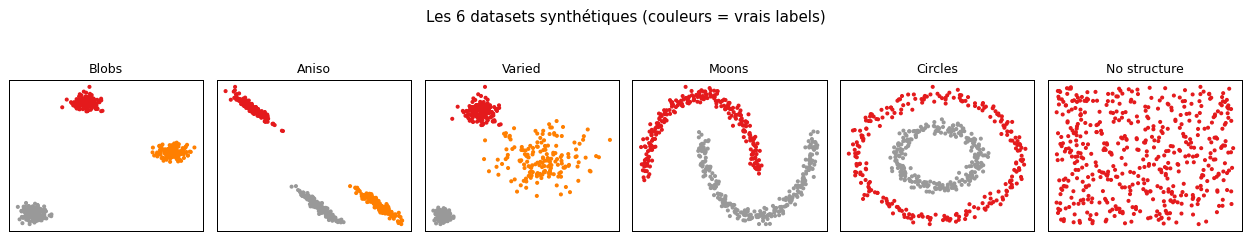

In [2]:
def make_datasets(n=500, seed=42):
    rs = np.random.RandomState(seed)
    X1, y1 = make_blobs(n_samples=n, centers=3, cluster_std=0.6, random_state=seed)
    X1 = StandardScaler().fit_transform(X1)

    X2, y2 = make_blobs(n_samples=n, centers=3, cluster_std=0.8, random_state=seed)
    T = np.array([[0.6, -0.6], [-0.4, 0.8]])  # transformation anisotrope
    X2 = StandardScaler().fit_transform(X2 @ T)

    X3, y3 = make_blobs(n_samples=n, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=seed)
    X3 = StandardScaler().fit_transform(X3)

    X4, y4 = make_moons(n_samples=n, noise=0.05, random_state=seed)
    X4 = StandardScaler().fit_transform(X4)

    X5, y5 = make_circles(n_samples=n, factor=0.5, noise=0.05, random_state=seed)
    X5 = StandardScaler().fit_transform(X5)

    X6 = rs.uniform(-2, 2, (n, 2))
    y6 = np.zeros(n, dtype=int)

    return {
        'Blobs':       (X1, y1, 3),
        'Aniso':       (X2, y2, 3),
        'Varied':      (X3, y3, 3),
        'Moons':       (X4, y4, 2),
        'Circles':     (X5, y5, 2),
        'No structure':(X6, y6, 1),
    }

datasets = make_datasets()

# Aperçu des 6 datasets
fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
for ax, (name, (X, y, k)) in zip(axes, datasets.items()):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, s=5)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Les 6 datasets synthétiques (couleurs = vrais labels)', y=1.05)
plt.tight_layout()
plt.show()

## 1. K-Means (Lloyd, 1982)

### 1.1 Intuition

Placer $k$ centroïdes dans l'espace pour que chaque point soit aussi proche que possible de son centroïde. Partition **dure** : chaque point appartient à un unique cluster.

### 1.2 Formulation

$$
J_{\text{KM}} = \sum_{i=1}^{n} \sum_{l=1}^{k} r_{il}\, \| x_i - m_l \|^2
$$

**Termes** :
- $r_{il} \in \{0, 1\}$ vaut 1 ssi le point $i$ est dans le cluster $l$ (assignation dure). Contrainte : $\sum_l r_{il} = 1$ pour tout $i$.
- $m_l \in \mathbb{R}^d$ est le centroïde du cluster $l$, défini comme la moyenne :

$$
m_l = \frac{1}{|C_l|} \sum_{x_i \in C_l} x_i
$$

- $\|x_i - m_l\|^2 = \sum_{j=1}^d (x_{ij} - m_{lj})^2$ est la distance euclidienne au carré.

Minimiser $J_{\text{KM}}$ revient à rendre les clusters **compacts**.

### 1.3 Convergence

L'algorithme alterne deux étapes qui font décroître $J_{\text{KM}}$ de manière monotone :

**Assignation** ($m$ fixes) : chaque point est assigné au centroïde le plus proche.
$$
r_{il} = \begin{cases} 1 & \text{si } l = \arg\min_{l'} \|x_i - m_{l'}\|^2 \\ 0 & \text{sinon} \end{cases}
$$

**Mise à jour** ($r$ fixes) : chaque centroïde devient la moyenne de ses points (la moyenne minimise la somme des carrés).

Comme $J_{\text{KM}} \geq 0$ et décroît, l'algorithme converge — mais vers un **minimum local**. L'initialisation `k-means++` (Arthur & Vassilvitskii, 2007) limite ce risque.

**Complexité** : $\mathcal{O}(nkd)$ par itération.

### 1.4 Implémentation *from scratch*

In [3]:
def kmeans_pp_init(X, k, rs):
    """Initialisation k-means++ : centres choisis loin les uns des autres."""
    n = len(X)
    centers = [X[rs.randint(n)]]
    for _ in range(1, k):
        # distance à la plus proche centre déjà choisi
        d2 = np.min([np.sum((X - c) ** 2, axis=1) for c in centers], axis=0)
        probs = d2 / d2.sum()
        idx = rs.choice(n, p=probs)
        centers.append(X[idx])
    return np.array(centers)

def kmeans(X, k, max_iter=100, tol=1e-4, seed=42):
    """K-Means implémenté à la main."""
    rs = np.random.RandomState(seed)
    m = kmeans_pp_init(X, k, rs)
    history = [m.copy()]

    for it in range(max_iter):
        # Assignation
        dists = np.sum((X[:, None, :] - m[None, :, :]) ** 2, axis=2)
        labels = dists.argmin(axis=1)

        # Mise à jour
        m_new = np.array([X[labels == l].mean(axis=0) if np.any(labels == l) else m[l] for l in range(k)])

        # Test de convergence
        if np.linalg.norm(m_new - m) < tol:
            m = m_new
            history.append(m.copy())
            break
        m = m_new
        history.append(m.copy())

    return labels, m, history

### 1.5 Visualisation : convergence des centroïdes

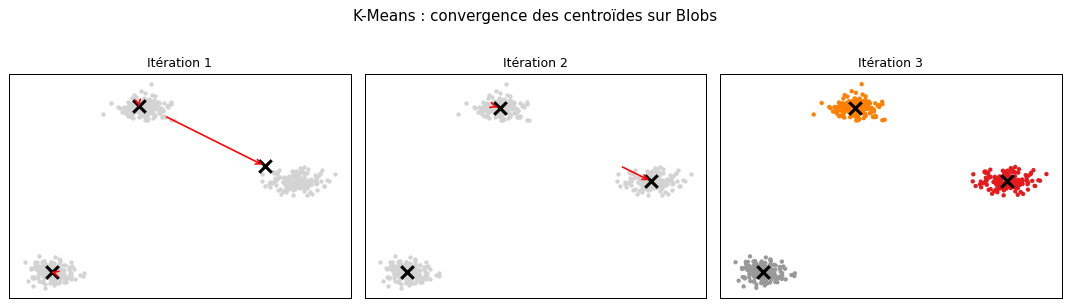

In [4]:
# Convergence sur Blobs
X, y, k = datasets['Blobs']
labels, centers, history = kmeans(X, k)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
for ax, i in zip(axes, [1, 2, len(history) - 1]):
    ax.scatter(X[:, 0], X[:, 1], c=labels if i == len(history) - 1 else 'lightgray', cmap=CMAP, s=6)
    ax.scatter(history[i][:, 0], history[i][:, 1], c='black', marker='x', s=100, linewidths=2.5)
    if i >= 1:
        for a, b in zip(history[i-1], history[i]):
            ax.annotate('', xy=b, xytext=a, arrowprops=dict(arrowstyle='->', color='red', lw=1.3))
    ax.set_title(f'Itération {i}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('K-Means : convergence des centroïdes sur Blobs', y=1.02)
plt.tight_layout()
plt.show()

### 1.6 Cellules de Voronoï : frontières toujours linéaires

K-Means partitionne l'espace en cellules de Voronoï. Les frontières sont **toujours des hyperplans** (droites en 2D). C'est pour cette raison structurelle que K-Means échoue sur les formes non-convexes.

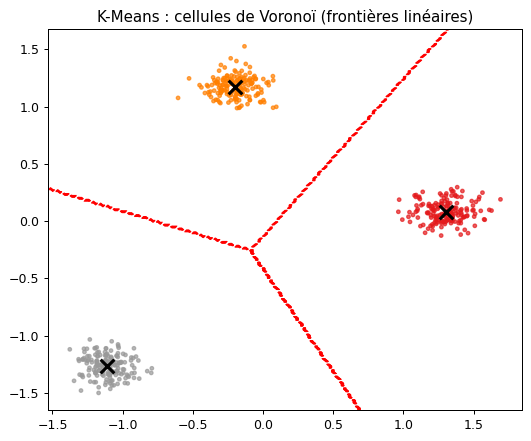

In [5]:
X, y, k = datasets['Blobs']
labels, centers, _ = kmeans(X, k)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], c=labels, cmap=CMAP, s=8, alpha=0.7)
ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='x', s=120, linewidths=2.5)

# Tracer les frontières via une grille fine
xx, yy = np.meshgrid(np.linspace(*ax.get_xlim(), 200), np.linspace(*ax.get_ylim(), 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_dist = np.sum((grid[:, None, :] - centers[None, :, :]) ** 2, axis=2)
grid_labels = grid_dist.argmin(axis=1).reshape(xx.shape)
ax.contour(xx, yy, grid_labels, colors='red', linestyles='--', linewidths=1.2)

ax.set_title('K-Means : cellules de Voronoï (frontières linéaires)')
plt.tight_layout()
plt.show()

### 1.7 Méthode du coude : choix de $k$

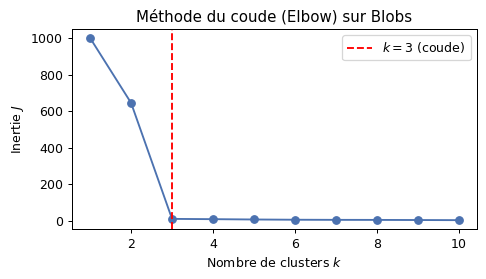

In [6]:
X, _, _ = datasets['Blobs']
ks = range(1, 11)
inertias = []
for k_test in ks:
    _, _, h = kmeans(X, k_test)
    labels_k, _, _ = kmeans(X, k_test)
    centers_k = np.array([X[labels_k == l].mean(axis=0) for l in range(k_test)])
    J = sum(np.sum((X[labels_k == l] - centers_k[l]) ** 2) for l in range(k_test))
    inertias.append(J)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(list(ks), inertias, 'o-', color='#4C72B0')
ax.axvline(3, color='red', linestyle='--', label='$k=3$ (coude)')
ax.set_xlabel('Nombre de clusters $k$')
ax.set_ylabel('Inertie $J$')
ax.set_title('Méthode du coude (Elbow) sur Blobs')
ax.legend()
plt.tight_layout()
plt.show()

### 1.8 Cas d'échec : hypothèses violées

K-Means suppose des clusters sphériques de tailles similaires. Quand ces hypothèses sont violées, il échoue.

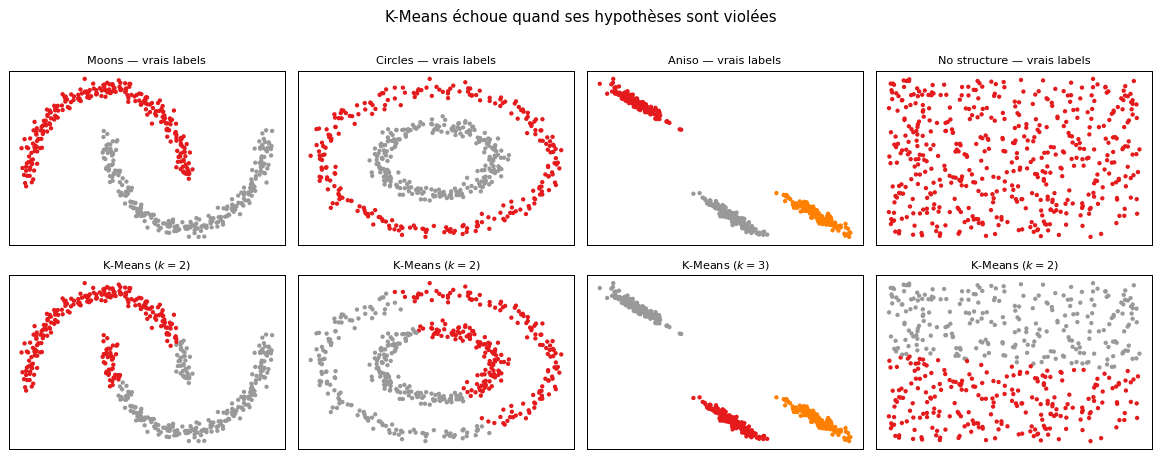

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5))
cases = ['Moons', 'Circles', 'Aniso', 'No structure']

for col, case in enumerate(cases):
    X, y, k_true = datasets[case]
    k_use = 2 if k_true in (1, 2) else 3
    # Vrais labels
    axes[0, col].scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, s=6)
    axes[0, col].set_title(f'{case} — vrais labels', fontsize=9)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    # K-Means
    labels_km, _, _ = kmeans(X, k_use)
    axes[1, col].scatter(X[:, 0], X[:, 1], c=labels_km, cmap=CMAP, s=6)
    axes[1, col].set_title(f'K-Means ($k={k_use}$)', fontsize=9)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.suptitle('K-Means échoue quand ses hypothèses sont violées', y=1.01)
plt.tight_layout()
plt.show()

## 2. Clustering hiérarchique — Ward (1963)

### 2.1 Intuition

Au lieu de fixer $k$ a priori, on construit un **dendrogramme** qui contient toutes les partitions possibles :

1. Chaque point commence seul ($n$ clusters singletons).
2. On fusionne les deux clusters les plus proches.
3. On recommence jusqu'à avoir un seul cluster.

On "coupe" ensuite le dendrogramme à la hauteur voulue pour obtenir $k$ clusters — sans recalculer.

### 2.2 Les quatre linkages

La question : comment définir la distance entre deux clusters $C_a$ et $C_b$ ?

**Single linkage** (distance minimale) :
$$d_{\text{single}}(C_a, C_b) = \min_{x \in C_a,\, y \in C_b} \|x - y\|$$
Détecte les formes allongées (chaînage) ; risque de fusions parasites.

**Complete linkage** (distance maximale) :
$$d_{\text{complete}}(C_a, C_b) = \max_{x \in C_a,\, y \in C_b} \|x - y\|$$
Clusters compacts au diamètre borné ; sensible aux outliers.

**Average linkage** (distance moyenne) :
$$d_{\text{avg}}(C_a, C_b) = \frac{1}{|C_a|\cdot|C_b|} \sum_{x \in C_a} \sum_{y \in C_b} \|x - y\|$$
Compromis single/complete.

**Ward** (augmentation minimale de variance) :
$$d_{\text{Ward}}(C_a, C_b) = \frac{|C_a| \cdot |C_b|}{|C_a| + |C_b|} \|m_a - m_b\|^2$$
où $m_a, m_b$ sont les centroïdes. Le facteur $|C_a||C_b|/(|C_a|+|C_b|)$ **pénalise les fusions de gros clusters** et favorise des partitions équilibrées. Ward minimise la même fonction objectif $J_{\text{KM}}$ que K-Means (équivalent hiérarchique).

**C'est le linkage utilisé par le CEA** pour initialiser les centres du FCM de manière déterministe.

### 2.3 Comparaison des 4 linkages sur Aniso

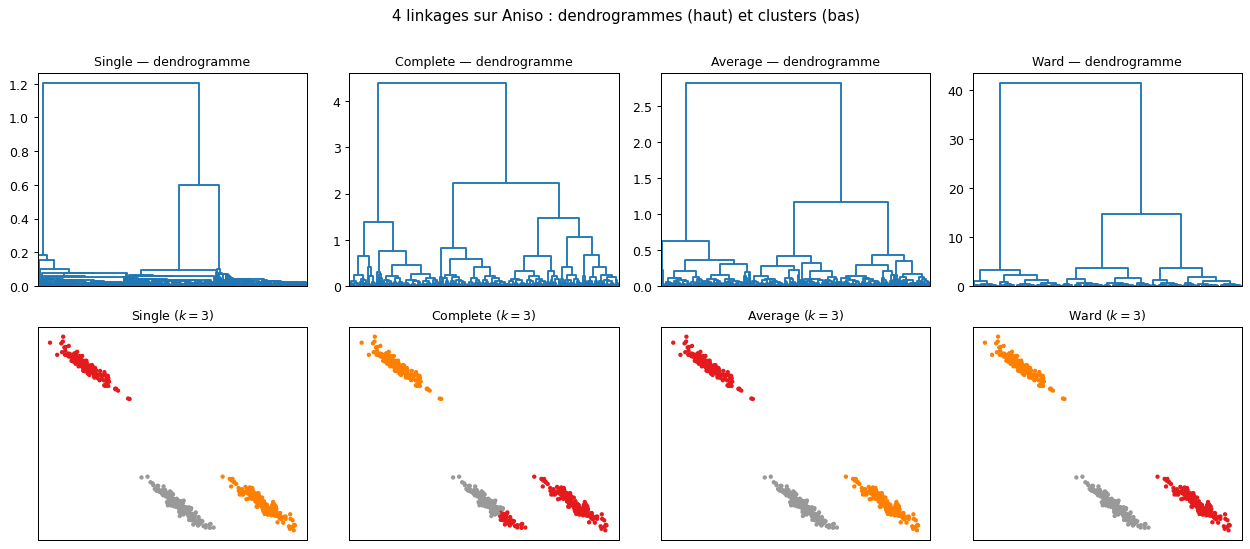

In [8]:
X, y, k = datasets['Aniso']

linkages = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for col, linkage_method in enumerate(linkages):
    # Dendrogramme
    Z = linkage(X, method=linkage_method)
    dendrogram(Z, ax=axes[0, col], no_labels=True, color_threshold=0)
    axes[0, col].set_title(f'{linkage_method.capitalize()} — dendrogramme', fontsize=10)
    axes[0, col].set_xticks([])

    # Coupe à k=3
    model = AgglomerativeClustering(n_clusters=3, linkage=linkage_method)
    labels = model.fit_predict(X)
    axes[1, col].scatter(X[:, 0], X[:, 1], c=labels, cmap=CMAP, s=6)
    axes[1, col].set_title(f'{linkage_method.capitalize()} ($k=3$)', fontsize=10)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.suptitle('4 linkages sur Aniso : dendrogrammes (haut) et clusters (bas)', y=1.01)
plt.tight_layout()
plt.show()

**Interprétation.** Sur les blobs anisotropes :
- **Single** détecte les formes allongées par chaînage (la distance minimale suit la forme).
- **Complete** et **Average** produisent des résultats intermédiaires.
- **Ward** découpe les ellipses en blobs sphériques (même logique que K-Means).

### 2.4 Complexité

$\mathcal{O}(n^2 \log n)$ en temps, $\mathcal{O}(n^2)$ en mémoire. Impraticable pour $n > 10^5$ (exclut Ward sur `covertype`, 581k lignes).

## 3. Fuzzy C-Means (Bezdek, 1984)

### 3.1 Intuition

K-Means impose une partition dure : chaque point appartient à **un seul** cluster. FCM produit une **partition floue** : chaque point appartient à **tous** les clusters avec un degré $\mu_{ci} \in [0, 1]$, sous la contrainte :

$$\sum_{c=1}^k \mu_{ci} = 1, \qquad \mu_{ci} \geq 0.$$

Cette nuance est essentielle pour le pipeline du projet : chaque cluster génère une **règle floue**, et $\mu_{ci}$ pondère la contribution de chaque règle à la prédiction finale (système d'inférence de Sugeno).

### 3.2 Formulation

$$
J_{\text{FCM}} = \sum_{i=1}^n \sum_{c=1}^k \mu_{ci}^{\,m} \|x_i - m_c\|^2
$$

$m > 1$ est le **fuzzifier**. Il contrôle le degré de flou :
- $m \to 1^+$ : partition quasi-dure (les $\mu$ tendent vers $\{0, 1\}$).
- $m = 2$ : valeur **standard** (compromis flou informatif / clusters bien définis).
- $m \to \infty$ : $\mu \to 1/k$ (uniforme), structure dissolue.

### 3.3 Mise à jour des appartenances

Par les conditions KKT du Lagrangien associé à $J_{\text{FCM}}$ sous la contrainte $\sum_c \mu_{ci} = 1$ :

$$
\mu_{ci} = \left( \sum_{c'=1}^k \left( \frac{\|x_i - m_c\|}{\|x_i - m_{c'}\|} \right)^{\!\frac{2}{m-1}} \right)^{\!-1}
$$

**Lecture** :
- Si $x_i$ est proche de $m_c$ : le ratio est petit pour tout $c' \neq c$, donc la somme est petite, l'inverse grand : $\mu_{ci} \approx 1$.
- Si $x_i$ est équidistant de tous les centres : $\mu_{ci} = 1/k$ pour tout $c$ (totalement ambigu).

### 3.4 Mise à jour des centres

$$
m_c = \frac{\sum_{i=1}^n \mu_{ci}^{\,m}\, x_i}{\sum_{i=1}^n \mu_{ci}^{\,m}}
$$

C'est une **moyenne pondérée** : les points avec $\mu_{ci} \approx 1$ tirent fortement le centre, les points ambigus contribuent peu. Pour $m = 1$, on retrouve la moyenne simple de K-Means.

### 3.5 Implémentation *from scratch*

In [9]:
def fuzzy_cmeans(X, k, m=2.0, max_iter=200, tol=1e-6, seed=42):
    """Fuzzy C-Means implémenté à la main."""
    rs = np.random.RandomState(seed)
    n, d = X.shape

    # Initialisation aléatoire de U (k × n) avec normalisation par colonne
    U = rs.rand(k, n)
    U /= U.sum(axis=0, keepdims=True)

    for it in range(max_iter):
        # Centres : moyennes pondérées
        Um = U ** m  # (k, n)
        centers = (Um @ X) / Um.sum(axis=1, keepdims=True)  # (k, d)

        # Distances (n, k)
        dists = np.sqrt(np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2) + 1e-12)

        # Mise à jour des appartenances
        exponent = 2.0 / (m - 1)
        ratios = dists[:, :, None] / dists[:, None, :]  # (n, k, k)
        U_new = 1.0 / (ratios ** exponent).sum(axis=2)  # (n, k)
        U_new = U_new.T  # (k, n)

        if np.max(np.abs(U_new - U)) < tol:
            U = U_new
            break
        U = U_new

    labels = U.argmax(axis=0)
    return labels, centers, U

# Test sur Varied (clusters de tailles différentes)
X, y, k = datasets['Varied']
labels_fcm, centers_fcm, U = fuzzy_cmeans(X, k)
print(f'FCM convergé. U shape={U.shape} (k×n). Exemple d\'appartenances pour le point 0 : {U[:, 0]}')

FCM convergé. U shape=(3, 500) (k×n). Exemple d'appartenances pour le point 0 : [0.00215104 0.00232896 0.99552   ]


### 3.6 K-Means dur vs FCM flou

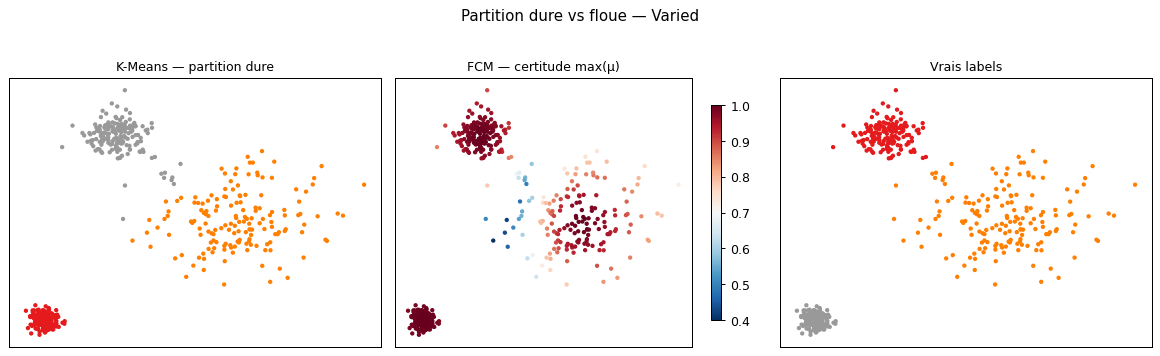

In [10]:
X, y, k = datasets['Varied']
labels_km, _, _ = kmeans(X, k)
labels_fcm, centers_fcm, U = fuzzy_cmeans(X, k)

# Certitude d'appartenance = max(μ_ci) pour chaque point
certitude = U.max(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

axes[0].scatter(X[:, 0], X[:, 1], c=labels_km, cmap=CMAP, s=6)
axes[0].set_title('K-Means — partition dure', fontsize=10)
axes[0].set_xticks([]); axes[0].set_yticks([])

sc = axes[1].scatter(X[:, 0], X[:, 1], c=certitude, cmap='RdBu_r', s=6, vmin=0.4, vmax=1.0)
axes[1].set_title('FCM — certitude max(μ)', fontsize=10)
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(sc, ax=axes[1], shrink=0.8)

axes[2].scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, s=6)
axes[2].set_title('Vrais labels', fontsize=10)
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle('Partition dure vs floue — Varied', y=1.03)
plt.tight_layout()
plt.show()

**Interprétation.** Les points rouges (FCM) sont fermement assignés ($\mu \approx 1$). Les points bleus sont ambigus — à la frontière entre clusters. K-Means force un choix binaire pour ces points, perdant l'information d'incertitude.

### 3.7 Effet du fuzzifier $m$

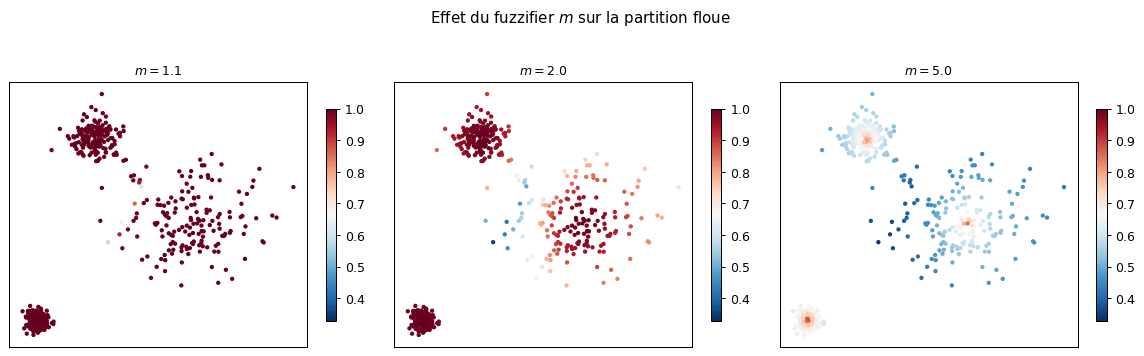

In [11]:
X, _, k = datasets['Varied']
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for ax, m in zip(axes, [1.1, 2.0, 5.0]):
    _, _, U_m = fuzzy_cmeans(X, k, m=m)
    certitude = U_m.max(axis=0)
    sc = ax.scatter(X[:, 0], X[:, 1], c=certitude, cmap='RdBu_r', s=6, vmin=0.33, vmax=1.0)
    ax.set_title(f'$m = {m}$', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, shrink=0.8)

plt.suptitle('Effet du fuzzifier $m$ sur la partition floue', y=1.03)
plt.tight_layout()
plt.show()

## 4. DBSCAN (Ester, 1996) — hors benchmark

### 4.1 Intuition

DBSCAN détecte les clusters comme des **régions denses** séparées par des zones de faible densité. Contrairement aux trois méthodes précédentes, il :
- ne suppose **aucune forme** pour les clusters
- identifie les **outliers** comme points isolés
- ne requiert pas de fixer $k$ à l'avance

### 4.2 Définitions

On définit le **$\varepsilon$-voisinage** d'un point :
$$
N_\varepsilon(x_i) = \{ x_j \mid \|x_i - x_j\| \leq \varepsilon \}
$$

Puis trois catégories de points :

| Type | Condition | Interprétation |
|---|---|---|
| **Core** | $\|N_\varepsilon(x_i)\| \geq \text{minPts}$ | Au cœur d'une zone dense |
| **Border** | Voisin d'un core, mais pas core | En bordure d'un cluster |
| **Noise** | Ni core, ni border | Point isolé, aucun cluster |

Un **cluster DBSCAN** est un ensemble maximal de core points *densité-connectés* (chaîne de cores reliant les points), augmenté des border points rattachés.

### 4.3 Choix des paramètres

- $\varepsilon$ : par le **$k$-distance plot** — on trace, triées, les distances de chaque point à son $k$-ème voisin. On place $\varepsilon$ au coude.
- $\text{minPts}$ : heuristique $\geq d + 1$, souvent 5 en pratique.

**Complexité** : $\mathcal{O}(n \log n)$ avec un index spatial.

### 4.4 Succès sur les formes non-convexes

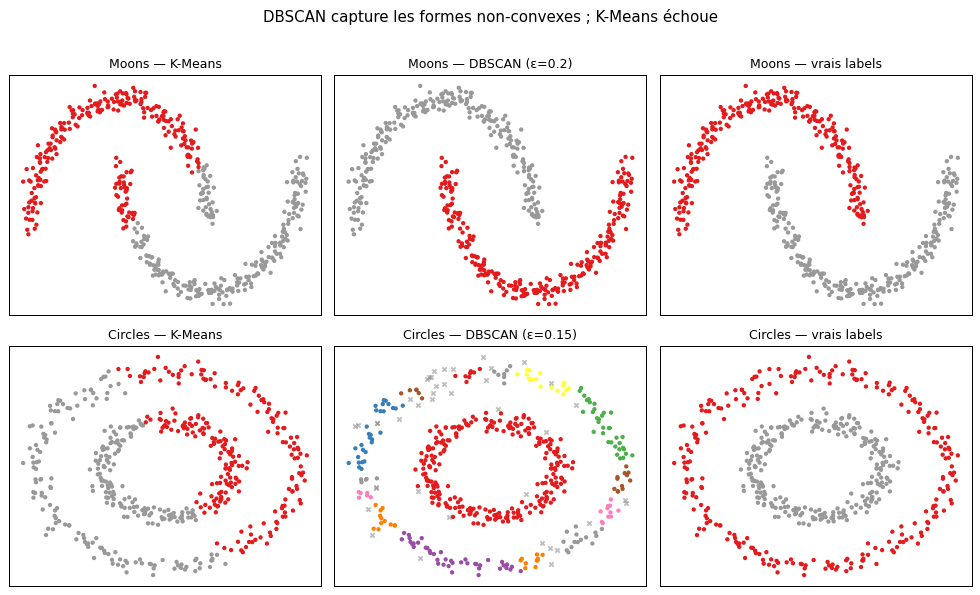

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5))
cases = ['Moons', 'Circles']

for row, case in enumerate(cases):
    X, y, _ = datasets[case]
    # K-Means
    labels_km, _, _ = kmeans(X, 2)
    axes[row, 0].scatter(X[:, 0], X[:, 1], c=labels_km, cmap=CMAP, s=6)
    axes[row, 0].set_title(f'{case} — K-Means', fontsize=10)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

    # DBSCAN
    eps = 0.2 if case == 'Moons' else 0.15
    db = DBSCAN(eps=eps, min_samples=5).fit(X)
    colors = np.where(db.labels_ == -1, -1, db.labels_)
    mask_noise = (db.labels_ == -1)
    axes[row, 1].scatter(X[~mask_noise, 0], X[~mask_noise, 1], c=db.labels_[~mask_noise], cmap=CMAP, s=6)
    axes[row, 1].scatter(X[mask_noise, 0], X[mask_noise, 1], c='gray', marker='x', s=12, alpha=0.5)
    axes[row, 1].set_title(f'{case} — DBSCAN (ε={eps})', fontsize=10)
    axes[row, 1].set_xticks([]); axes[row, 1].set_yticks([])

    # Vrais
    axes[row, 2].scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, s=6)
    axes[row, 2].set_title(f'{case} — vrais labels', fontsize=10)
    axes[row, 2].set_xticks([]); axes[row, 2].set_yticks([])

plt.suptitle('DBSCAN capture les formes non-convexes ; K-Means échoue', y=1.01)
plt.tight_layout()
plt.show()

### 4.5 Détection de l'absence de structure

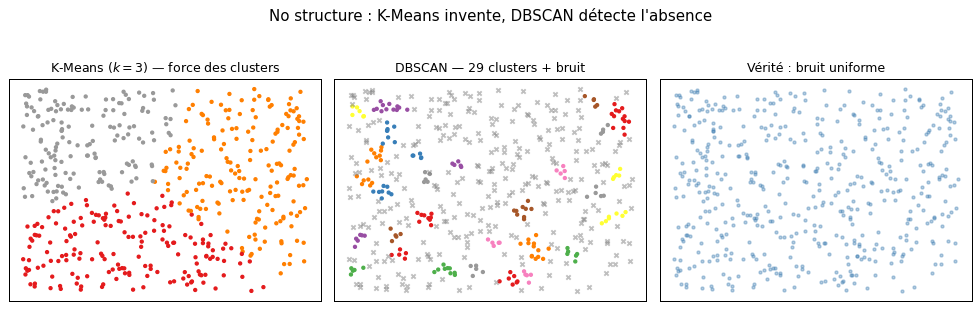

In [13]:
X, y, _ = datasets['No structure']
labels_km, _, _ = kmeans(X, 3)
db = DBSCAN(eps=0.15, min_samples=5).fit(X)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
axes[0].scatter(X[:, 0], X[:, 1], c=labels_km, cmap=CMAP, s=6)
axes[0].set_title('K-Means ($k=3$) — force des clusters', fontsize=10)

mask = db.labels_ == -1
axes[1].scatter(X[~mask, 0], X[~mask, 1], c=db.labels_[~mask], cmap=CMAP, s=6)
axes[1].scatter(X[mask, 0], X[mask, 1], c='gray', marker='x', s=12, alpha=0.5)
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
axes[1].set_title(f'DBSCAN — {n_clusters} clusters + bruit', fontsize=10)

axes[2].scatter(X[:, 0], X[:, 1], c='steelblue', s=6, alpha=0.4)
axes[2].set_title('Vérité : bruit uniforme', fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("No structure : K-Means invente, DBSCAN détecte l'absence", y=1.03)
plt.tight_layout()
plt.show()

### 4.6 Pourquoi DBSCAN est *hors benchmark*

DBSCAN est incompatible avec le pipeline de règles floues du projet, pour quatre raisons concrètes :

| Limitation | Conséquence |
|---|---|
| **Pas de centroïdes** | Impossible de construire les règles de Sugeno $\hat{y}(x) = \sum_c \mu_c(x) \cdot (\alpha_c^\top x + \beta_c)$ |
| **Pas de partition floue** | Aucun degré $\mu_{ci}$ pour pondérer les règles |
| **Points bruit non assignés** | Des observations sont perdues dans la modélisation |
| **Sensible à $\varepsilon$ en haute dimension** | Concentration des distances — choix de $\varepsilon$ délicat |

DBSCAN reste utile pour l'**analyse exploratoire** (détection d'anomalies, formes complexes), mais sort du benchmark final.

## 5. Comparaison synthétique des 4 méthodes

### 5.1 Récapitulatif

| | K-Means | Ward | FCM | DBSCAN |
|---|---|---|---|---|
| **Famille** | Partit. dur | Hiérarchique | Partit. flou | Densité |
| **Paramètres** | $k$ | $k$, linkage | $k$, $m$ | $\varepsilon$, minPts |
| **Forme** | Sphérique | Sphérique (Ward) | Sphérique | Arbitraire |
| **Complexité** | $\mathcal{O}(nkd)$ | $\mathcal{O}(n^2 \log n)$ | $\mathcal{O}(nkd)$ | $\mathcal{O}(n \log n)$ |
| **Outliers** | Non | Non | Non | **Oui** |
| **Rôle projet** | Test robust. | Init. FCM | **Central** | Hors bench. |

### 5.2 Grille comparative : 4 algorithmes × 6 datasets

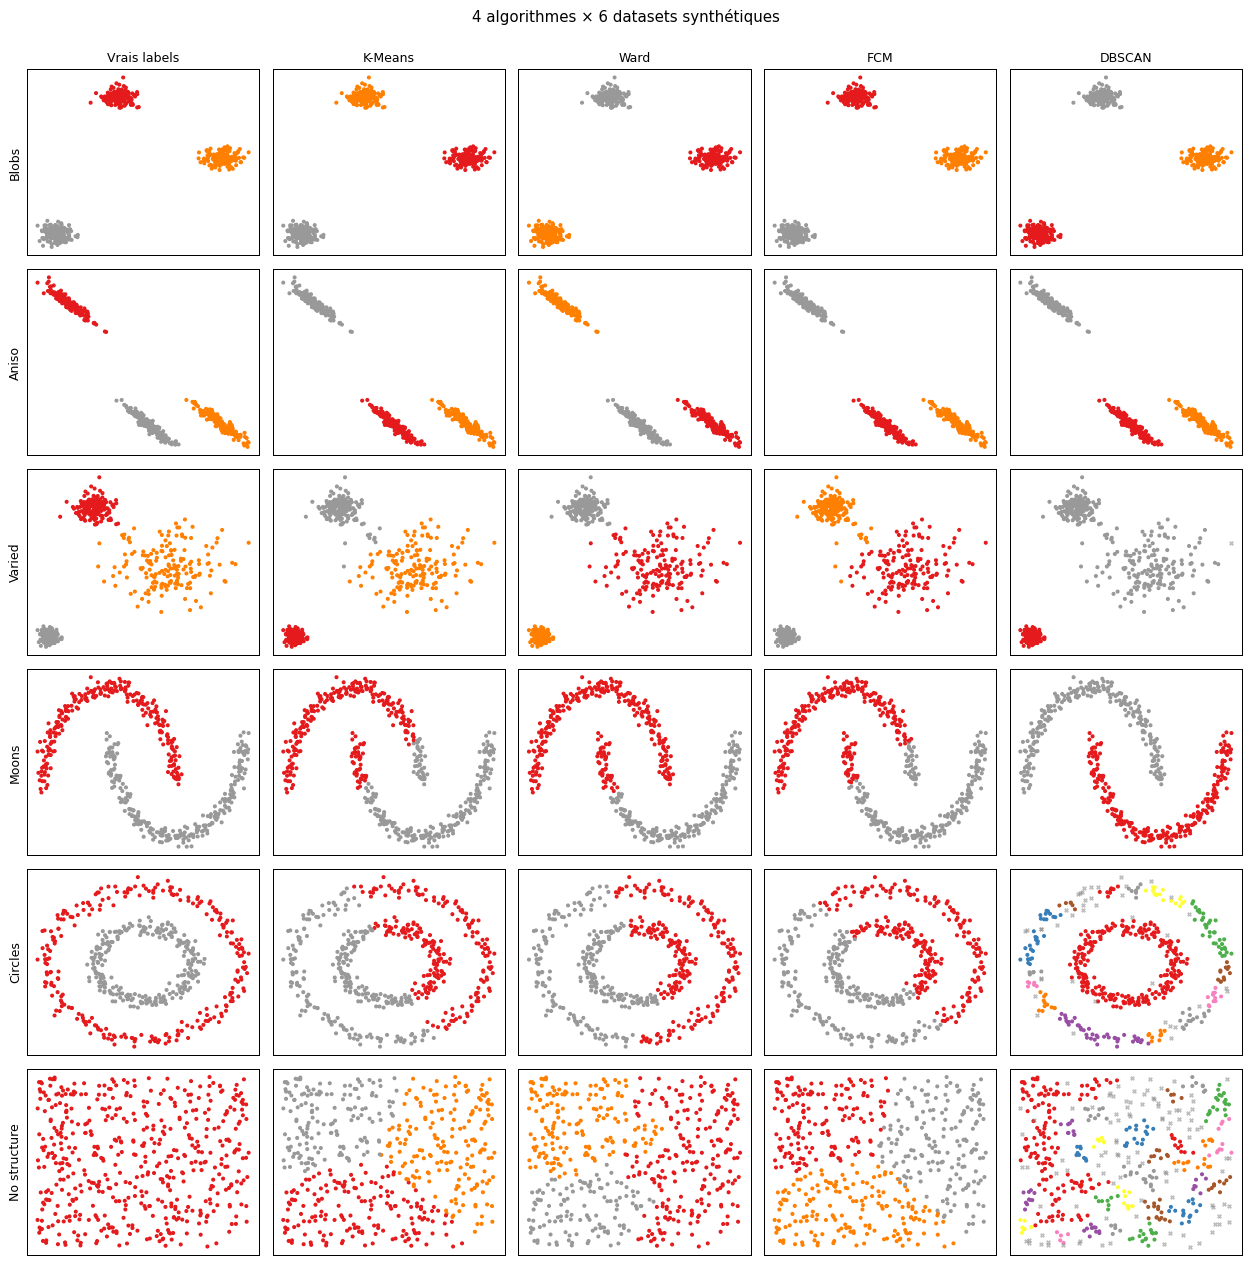

In [14]:
fig, axes = plt.subplots(6, 5, figsize=(14, 14))
dataset_names = list(datasets.keys())

for row, name in enumerate(dataset_names):
    X, y, k_true = datasets[name]
    k_use = max(2, k_true) if k_true > 1 else 3

    # Vrais labels
    axes[row, 0].scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, s=5)
    axes[row, 0].set_title('Vrais labels' if row == 0 else '', fontsize=10)
    axes[row, 0].set_ylabel(name, fontsize=10)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

    # K-Means
    labels_km, _, _ = kmeans(X, k_use)
    axes[row, 1].scatter(X[:, 0], X[:, 1], c=labels_km, cmap=CMAP, s=5)
    axes[row, 1].set_title('K-Means' if row == 0 else '', fontsize=10)
    axes[row, 1].set_xticks([]); axes[row, 1].set_yticks([])

    # Ward
    labels_w = AgglomerativeClustering(n_clusters=k_use, linkage='ward').fit_predict(X)
    axes[row, 2].scatter(X[:, 0], X[:, 1], c=labels_w, cmap=CMAP, s=5)
    axes[row, 2].set_title('Ward' if row == 0 else '', fontsize=10)
    axes[row, 2].set_xticks([]); axes[row, 2].set_yticks([])

    # FCM
    labels_f, _, _ = fuzzy_cmeans(X, k_use)
    axes[row, 3].scatter(X[:, 0], X[:, 1], c=labels_f, cmap=CMAP, s=5)
    axes[row, 3].set_title('FCM' if row == 0 else '', fontsize=10)
    axes[row, 3].set_xticks([]); axes[row, 3].set_yticks([])

    # DBSCAN
    eps = {'Blobs':0.3, 'Aniso':0.3, 'Varied':0.4, 'Moons':0.2, 'Circles':0.15, 'No structure':0.2}[name]
    db = DBSCAN(eps=eps, min_samples=5).fit(X)
    mask = db.labels_ == -1
    axes[row, 4].scatter(X[~mask, 0], X[~mask, 1], c=db.labels_[~mask], cmap=CMAP, s=5)
    axes[row, 4].scatter(X[mask, 0], X[mask, 1], c='gray', marker='x', s=8, alpha=0.5)
    axes[row, 4].set_title('DBSCAN' if row == 0 else '', fontsize=10)
    axes[row, 4].set_xticks([]); axes[row, 4].set_yticks([])

plt.suptitle('4 algorithmes × 6 datasets synthétiques', y=1.00, fontsize=12)
plt.tight_layout()
plt.show()

**Lecture de la grille** :

- **Blobs** : tous réussissent (cas standard).
- **Aniso** : K-Means, Ward, FCM coupent les ellipses en blobs sphériques ; DBSCAN s'adapte mieux.
- **Varied** : K-Means tend à égaliser les tailles ; DBSCAN peut rater le petit cluster.
- **Moons, Circles** : seul DBSCAN réussit. Les trois autres échouent (frontières linéaires).
- **No structure** : K-Means, Ward, FCM *inventent* des clusters ; DBSCAN détecte l'absence de structure (clusters + bruit).

### 5.3 Synthèse : quand utiliser quel algorithme

| Situation | Algorithme recommandé | Pourquoi |
|---|---|---|
| Clusters globulaires, $k$ connu | **K-Means** | Rapide, simple, scalable |
| Structure hiérarchique à explorer | **Ward** | Le dendrogramme révèle les niveaux |
| Frontières ambiguës, règles floues | **FCM** | Partition floue, compatible Sugeno |
| Formes arbitraires, outliers | **DBSCAN** | Pas d'hypothèse de forme |
| Pipeline complet du projet | **FCM initialisé par Ward** | Déterministe + flou |

## 6. Conclusion

Les quatre algorithmes sont **implémentés et caractérisés géométriquement** sur les 6 datasets synthétiques. Le pipeline retenu pour le projet est **FCM initialisé par Ward** :
- Ward fournit des centres initiaux déterministes (pas d'aléa à chaque run).
- FCM apporte la partition floue indispensable au système de Sugeno.
- K-Means et Ward (seuls) serviront à **tester la robustesse** des méthodes de sélection dans le notebook 4.
- DBSCAN reste hors benchmark mais utile pour l'analyse exploratoire.

**Étape suivante** : le notebook 3 présente les méthodes de sélection de variables qui permettent de réduire $d$ avant d'appliquer ces algorithmes.